In [1]:
from __future__ import annotations
import pandas as pd
from pathlib import Path
from datetime import datetime, timedelta

def find_public_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "challenge" / "release" / "v1" / "public",
        Path.cwd() / "challenge" / "bundle" / "v1" / "participant_package",
        Path.cwd().parent,
        Path.cwd().parent / "public",
    ]
    for candidate in candidates:
        # Fixed: Check for both .zip and .csv versions of the data
        has_data = (candidate / "reefer_release.zip").exists() or (candidate / "reefer_release.csv").exists()
        if has_data and (candidate / "target_timestamps.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate the participant data directory with reefer_release.csv/zip.")

PUBLIC_DIR = find_public_dir()
REEFER_CSV = PUBLIC_DIR / "reefer_release.csv"
TARGETS_CSV = PUBLIC_DIR / "target_timestamps.csv"

# Faster Data Loading with Pandas
print("Loading target hours...")
target_hours = pd.read_csv(TARGETS_CSV)['timestamp_utc'].pipe(pd.to_datetime)

print(f"Loading and aggregating {REEFER_CSV.name} (this may take a few seconds)...")
# Note: Using sep=';' and decimal=',' based on your CSV format
df = pd.read_csv(REEFER_CSV, sep=';', decimal=',', usecols=['EventTime', 'AvPowerCons'])
df['EventTime'] = pd.to_datetime(df['EventTime'])
df['hour'] = df['EventTime'].dt.floor('h')

# Aggregate hourly load in kW
hourly_load_kw = df.groupby('hour')['AvPowerCons'].sum() / 1000.0
print(f"Loaded {len(hourly_load_kw)} hours of data.")


Loading target hours...
Loading and aggregating reefer_release.csv (this may take a few seconds)...
Loaded 8403 hours of data.


In [3]:
# --- Step 2: Build the Naive Baseline ---
def naive_baseline(hourly_load_series, target_timestamps):
    predictions = []
    
    # Calculate an overall hourly average as an absolute fallback
    hourly_averages = hourly_load_series.groupby(hourly_load_series.index.hour).mean()
    
    for ts in target_timestamps:
        yesterday = ts - pd.Timedelta(hours=24)
        two_days = ts - pd.Timedelta(hours=48)
        
        # Look for yesterday, then two days ago, then fallback to historical hourly average
        if yesterday in hourly_load_series.index:
            pred = hourly_load_series.loc[yesterday]
        elif two_days in hourly_load_series.index:
            pred = hourly_load_series.loc[two_days]
        else:
            pred = hourly_averages[ts.hour]
            
        # P90 is estimated as a 10% uplift from the P50 prediction
        predictions.append({
            'timestamp_utc': ts,
            'pred_power_kw': pred,
            'pred_p90_kw': pred * 1.10  
        })
    
    return pd.DataFrame(predictions)

print("Generating baseline predictions...")
submission_raw = naive_baseline(hourly_load_kw, target_hours)
print(f"Generated {len(submission_raw)} predictions.")

# --- Step 3: Format, Validate, and Save ---
def format_and_validate(sub, targets_series):
    out = sub.copy()
    
    # Force ISO 8601 format: 2026-01-01T00:00:00Z
    out['timestamp_utc'] = pd.to_datetime(out['timestamp_utc']).dt.strftime('%Y-%m-%dT%H:%M:%SZ')
    
    # Round to 2 decimal places as required
    out['pred_power_kw'] = out['pred_power_kw'].round(2)
    out['pred_p90_kw'] = out['pred_p90_kw'].round(2)
    
    # Enforce strict column order
    out = out[['timestamp_utc', 'pred_power_kw', 'pred_p90_kw']]
    
    # Validation checks to ensure the organizers' script won't crash
    sub_ts = set(pd.to_datetime(out['timestamp_utc']))
    target_ts = set(pd.to_datetime(targets_series))
    
    assert len(target_ts - sub_ts) == 0, f"Missing {len(target_ts - sub_ts)} target timestamps!"
    assert len(sub_ts - target_ts) == 0, "Extra timestamps found in submission!"
    assert out.duplicated(subset='timestamp_utc').sum() == 0, "Duplicate timestamps detected!"
    assert (out['pred_power_kw'].astype(float) >= 0).all(), "Negative pred_power_kw values found!"
    assert (out['pred_p90_kw'].astype(float) >= out['pred_power_kw'].astype(float)).all(), "P90 constraint violation: P90 is lower than P50!"
    
    print("✓ All validation checks passed cleanly.")
    return out

# Apply formatting and validation
submission_final = format_and_validate(submission_raw, target_hours)

# Save the valid submission
output_path = Path.cwd() / 'predictions.csv'
submission_final.to_csv(output_path, index=False)

print(f"\nSaved Level 0 submission to: {output_path}")
display(submission_final.head(3))

Generating baseline predictions...
Generated 223 predictions.
✓ All validation checks passed cleanly.

Saved Level 0 submission to: /Users/ashutoshchatterjee/Documents/Projects/eurogate/predictions.csv


,timestamp_utc,pred_power_kw,pred_p90_kw
0,2026-01-01T00:00:00Z,1033.26,1136.59
1,2026-01-01T01:00:00Z,1026.68,1129.35
2,2026-01-01T02:00:00Z,1021.92,1124.11


EDA

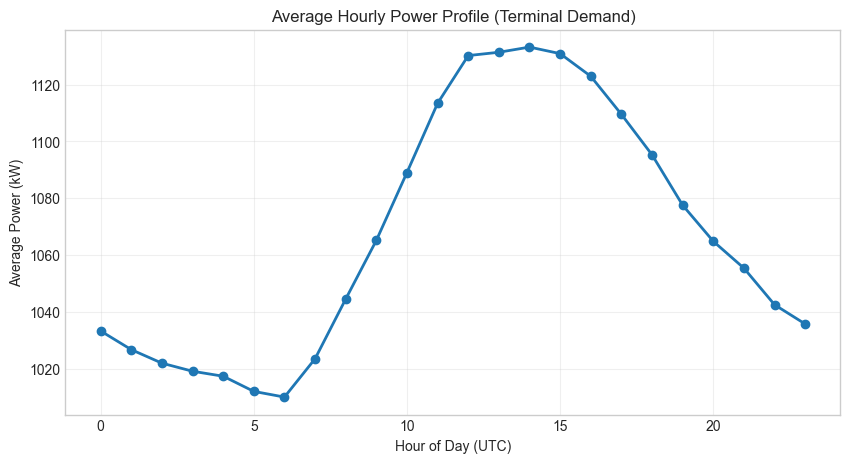

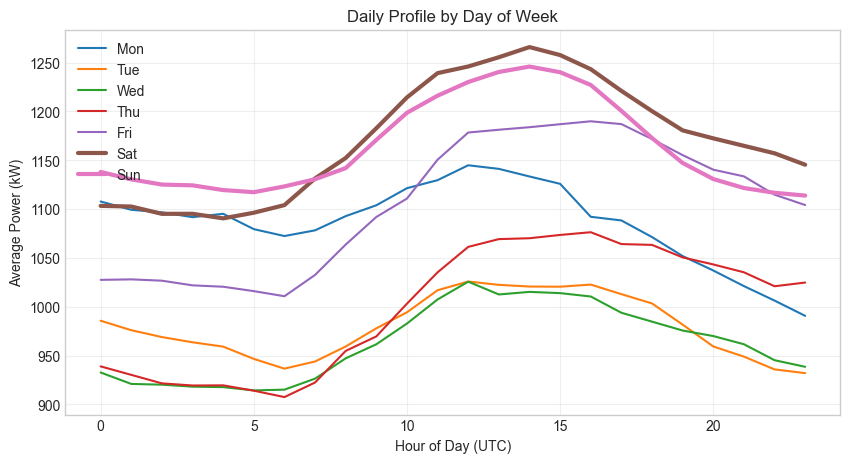

In [7]:
import matplotlib.pyplot as plt

# Ensure plots show up in the notebook
%matplotlib inline

# 1. Daily Profile
plt.figure(figsize=(10, 5))
hourly_profile = hourly_load_kw.groupby(hourly_load_kw.index.hour).mean()
plt.plot(hourly_profile.index, hourly_profile.values, marker='o', linewidth=2)
plt.title('Average Hourly Power Profile (Terminal Demand)')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Average Power (kW)')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Weekday vs Weekend Profile
plt.figure(figsize=(10, 5))
df_plot = hourly_load_kw.reset_index()
df_plot.columns = ['timestamp', 'power_kw']
df_plot['dow'] = df_plot['timestamp'].dt.dayofweek
df_plot['hour'] = df_plot['timestamp'].dt.hour

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for dow in range(7):
    subset = df_plot[df_plot['dow'] == dow]
    profile = subset.groupby('hour')['power_kw'].mean()
    # Thicker lines for weekend to make them stand out
    lw = 3 if dow >= 5 else 1.5 
    plt.plot(profile.index, profile.values, label=days[dow], linewidth=lw)

plt.title('Daily Profile by Day of Week')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Average Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Map the path to the Wetterdaten folder
weather_dir = PUBLIC_DIR / "Wetterdaten Okt 25 - 23 Feb 26"

# Let's start with the Zentralgate temperature
temp_file = weather_dir / "CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26.csv"

print(f"Loading weather from: {temp_file.name}")
try:
    # Assuming the same sep/decimal format as your reefer data
    weather_df = pd.read_csv(temp_file, sep=';', decimal=',')
    display(weather_df.head())
    print("\nColumns:", weather_df.columns.tolist())
except Exception as e:
    print(f"Failed to load. Might need format tweaking: {e}")

Loading weather from: CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26.csv


,ConfigID,UtcTimestamp,TimeResolution,Quality,Value
0,43805,2025-09-24 10:00:50.943,40.0,192,13.2
1,43805,2025-10-10 09:59:44.277,40.0,192,14.7
2,43805,2025-10-10 09:59:53.283,20.0,192,14.8
3,43805,2025-10-10 10:06:57.277,30.0,192,14.9
4,43805,2025-10-10 10:10:42.277,30.0,192,15.0



Columns: ['ConfigID', 'UtcTimestamp', 'TimeResolution', 'Quality', 'Value']


In [10]:
# Quick diagnostic to find the right delimiter
temp_file = weather_dir / "CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26.csv"

print("Raw text of the first 3 lines:")
with open(temp_file, 'r') as f:
    for i in range(3):
        print(repr(f.readline()))

Raw text of the first 3 lines:
'\ufeffConfigID;UtcTimestamp;TimeResolution;Quality;Value\n'
'43805;2025-09-24 10:00:50.943;40;192;13,2\n'
'43805;2025-10-10 09:59:44.277;40;192;14,7\n'


In [11]:
# --- Cell 4: Process and Merge Weather Data ---

def process_weather_file(file_path, col_name):
    print(f"Processing: {file_path.name}...")
    # encoding='utf-8-sig' automatically strips the \ufeff BOM
    df = pd.read_csv(
        file_path, 
        sep=';', 
        decimal=',', 
        encoding='utf-8-sig', 
        usecols=['UtcTimestamp', 'Value']
    )
    # Convert to datetime and floor to the nearest hour
    df['UtcTimestamp'] = pd.to_datetime(df['UtcTimestamp'])
    df['hour'] = df['UtcTimestamp'].dt.floor('h')
    
    # Average the sub-minute readings into hourly readings
    return df.groupby('hour')['Value'].mean().rename(col_name)

# 1. Convert our target Series into a DataFrame to prepare for feature merging
df_features = hourly_load_kw.to_frame(name='target_kw')

# 2. Load the key weather files (Zentralgate represents the terminal well)
temp_file = weather_dir / "CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26.csv"
wind_file = weather_dir / "CTH_Wind_Zentralgate  Okt 25 - 23 Feb 26.csv"

temp_series = process_weather_file(temp_file, 'temp_c')
wind_series = process_weather_file(wind_file, 'wind_speed')

# 3. Merge weather into the main dataframe (Left join to keep all target hours)
df_features = df_features.join(temp_series, how='left')
df_features = df_features.join(wind_series, how='left')

# 4. Interpolate small gaps (weather sensors sometimes go offline for an hour)
df_features['temp_c'] = df_features['temp_c'].interpolate(method='linear', limit=3)
df_features['wind_speed'] = df_features['wind_speed'].interpolate(method='linear', limit=3)

print(f"\nMissing Temperature hours after interpolation: {df_features['temp_c'].isna().sum()}")
print(f"Missing Wind hours after interpolation: {df_features['wind_speed'].isna().sum()}")

print("\nMaster Feature DataFrame Ready:")
display(df_features.head())

Processing: CTH_Temperatur_Zentralgate  Okt 25 - 23 Feb 26.csv...
Processing: CTH_Wind_Zentralgate  Okt 25 - 23 Feb 26.csv...

Missing Temperature hours after interpolation: 6237
Missing Wind hours after interpolation: 6237

Master Feature DataFrame Ready:


,target_kw,temp_c,wind_speed
hour,,,
2025-01-01 00:00:00,843.247345,NaN,NaN
2025-01-01 01:00:00,866.865919,NaN,NaN
2025-01-01 02:00:00,865.292780,NaN,NaN
2025-01-01 03:00:00,875.907910,NaN,NaN
2025-01-01 04:00:00,873.150000,NaN,NaN


In [12]:
import numpy as np

def evaluate_model(actual, predicted, predicted_p90):
    """
    Replicates the exact competition scoring formula.
    Lower score is better.
    """
    actual = np.array(actual)
    predicted = np.array(predicted)
    predicted_p90 = np.array(predicted_p90)
    
    # 1. MAE All (50% weight)
    mae_all = np.mean(np.abs(actual - predicted))
    
    # 2. MAE Peak (30% weight) - Assuming top 25% of load is considered "peak"
    threshold = np.percentile(actual, 75)
    peak_mask = actual >= threshold
    mae_peak = np.mean(np.abs(actual[peak_mask] - predicted[peak_mask]))
    
    # 3. Pinball P90 (20% weight) - Penalizes undershooting 9x more than overshooting
    error = actual - predicted_p90
    pinball_p90 = np.mean(np.where(error > 0, 0.9 * error, -0.1 * error))
    
    # Combine
    score = (0.5 * mae_all) + (0.3 * mae_peak) + (0.2 * pinball_p90)
    
    return {
        'Combined Score': round(score, 2),
        'MAE All': round(mae_all, 2),
        'MAE Peak': round(mae_peak, 2),
        'Pinball P90': round(pinball_p90, 2)
    }

print("Validation framework ready.")

Validation framework ready.


In [13]:
# --- Cell 5: Feature Engineering (Strictly No Leakage) ---

# 1. Drop the months where we have no weather data
df_clean = df_features.dropna(subset=['temp_c', 'wind_speed']).copy()
print(f"Data remaining after dropping unaligned weather: {len(df_clean)} hours")

# 2. Time/Calendar Features
df_clean['hour'] = df_clean.index.hour
df_clean['dow'] = df_clean.index.dayofweek
df_clean['is_weekend'] = (df_clean['dow'] >= 5).astype(int)

# 3. Lag Features (What was the power usage in the past?)
# MUST shift by >= 24 to mimic a 24-hour ahead forecast
df_clean['lag_24h'] = df_clean['target_kw'].shift(24)
df_clean['lag_48h'] = df_clean['target_kw'].shift(48)
df_clean['lag_168h'] = df_clean['target_kw'].shift(168) # Exactly 1 week ago

# 4. Rolling Features (Recent trends, also shifted by 24h)
df_clean['rolling_mean_24h'] = df_clean['target_kw'].shift(24).rolling(window=24).mean()
df_clean['rolling_max_24h'] = df_clean['target_kw'].shift(24).rolling(window=24).max()

# Drop the new NaNs created by our 168-hour shift (loses the first week of October)
df_model = df_clean.dropna().copy()
print(f"Final training rows after feature creation: {len(df_model)} hours")

# The features we will actually feed to the model
FEATURES = [
    'hour', 'dow', 'is_weekend', 
    'lag_24h', 'lag_48h', 'lag_168h', 
    'rolling_mean_24h', 'rolling_max_24h',
    'temp_c', 'wind_speed'
]
TARGET = 'target_kw'

Data remaining after dropping unaligned weather: 2166 hours
Final training rows after feature creation: 1998 hours


In [14]:
# --- Cell 6: Train LightGBM & Local Validation ---
from lightgbm import LGBMRegressor

# Split into Train and Validation (Let's hold out the last 14 days to test)
val_days = 14
split_date = df_model.index.max() - pd.Timedelta(days=val_days)

train = df_model[df_model.index <= split_date]
val = df_model[df_model.index > split_date]

print(f"Training on {len(train)} hours, Validating on {len(val)} hours...")

# Train P50 Model (alpha=0.5 optimizes for Mean Absolute Error)
model_p50 = LGBMRegressor(
    objective='quantile', alpha=0.5, 
    n_estimators=200, learning_rate=0.05, 
    random_state=42, verbose=-1
)
model_p50.fit(train[FEATURES], train[TARGET])

# Train P90 Model (alpha=0.9 optimizes for the asymmetric pinball loss)
model_p90 = LGBMRegressor(
    objective='quantile', alpha=0.9, 
    n_estimators=200, learning_rate=0.05, 
    random_state=42, verbose=-1
)
model_p90.fit(train[FEATURES], train[TARGET])

# Predict on our Validation set
val_preds_p50 = model_p50.predict(val[FEATURES])
val_preds_p90 = model_p90.predict(val[FEATURES])

# Enforce the competition rule: P90 must ALWAYS be >= P50
val_preds_p90 = np.maximum(val_preds_p50, val_preds_p90)

# Score it!
metrics = evaluate_model(val[TARGET], val_preds_p50, val_preds_p90)
print("\n--- LightGBM Local Validation Score ---")
for k, v in metrics.items():
    print(f"{k}: {v}")

OSError: dlopen(/Users/ashutoshchatterjee/Documents/Projects/eurogate/.venv/lib/python3.14/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <D44045CD-B874-3A27-9A61-F131D99AACE4> /Users/ashutoshchatterjee/Documents/Projects/eurogate/.venv/lib/python3.14/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/opt/homebrew/lib/li